In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
from transformers import GPT2Model

# get the Word Position Embeddings matrix
gpt2 = GPT2Model.from_pretrained('gpt2')
positions = gpt2.wpe.weight.detach().numpy()

/opt/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/anaconda3/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [3]:
# copied from "embed_positionEmbeddings.ipynb"

# cosine similarities for "time series" (token index)
Pnorm1 = positions / np.linalg.norm(positions,axis=1,keepdims=True)
cossim_tokens = Pnorm1 @ Pnorm1.T

# cosine similarities across embedding dimensions
Pnorm0 = positions / np.linalg.norm(positions,axis=0,keepdims=True)
cossim_embeds = Pnorm0.T @ Pnorm0

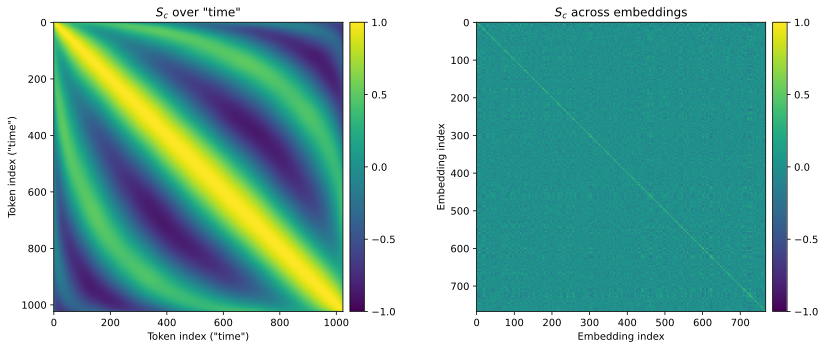

In [4]:
# draw the images (also copied from previous code file)
fig,axs = plt.subplots(1,2,figsize=(12,5))

h = axs[0].imshow(cossim_tokens,vmin=-1,vmax=1)
axs[0].set(xlabel='Token index ("time")',ylabel='Token index ("time")',title='$S_c$ over "time"')
ch = fig.colorbar(h,ax=axs[0],pad=.02,fraction=.046)
ch.ax.tick_params(labelsize=10)
ch.ax.set_yticks(np.arange(-1,1.1,.5))

h = axs[1].imshow(cossim_embeds,vmin=-1,vmax=1)
axs[1].set(xlabel='Embedding index',ylabel='Embedding index',title='$S_c$ across embeddings')
ch = fig.colorbar(h,ax=axs[1],pad=.02,fraction=.046)
ch.ax.tick_params(labelsize=10)
ch.ax.set_yticks(np.arange(-1,1.1,.5))

plt.tight_layout()
plt.show()